In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["Species"] = y

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [5]:
print("Number of Samples:", X.shape[0])
print("Number of Features:", X.shape[1])

print("Feature Names:")
print(iris.feature_names)

print("Target Classes:")
print(iris.target_names)

Number of Samples: 150
Number of Features: 4
Feature Names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Classes:
['setosa' 'versicolor' 'virginica']


In [6]:
print(df["Species"].value_counts())

0    50
1    50
2    50
Name: Species, dtype: int64


Dataset is balanced so we dont need class strafication

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 120
Testing Samples: 30


In [9]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


Creates a Decision Tree classifier. By default, in scikit-learn: criterion = "gini"
The model learns patterns from the training data. Then predicts flower classes for unseen test data.

In [11]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



Accuracy measures the percentage of correctly classified samples. Here it is 100%. Confusion Matrix shows correct and incorrect predictions for each class.

The report provides precision, recall, and F1-score.
Evaluates overall model performance.

In [22]:
from sklearn.tree import export_text

tree_rules = export_text(dt, feature_names=iris.feature_names)
print(tree_rules)

|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- petal width (cm) <= 1.55
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- petal width (cm) >  1.55
|   |   |   |   |   |--- petal length (cm) <= 5.45
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- petal length (cm) >  5.45
|   |   |   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- sepal width (cm) <= 3.10
|   |   |   |   |   |--- class: 2
|   |   |   |   |--- sepal width (cm) >  3.10
|   |   |   |   |   |--- class: 1
|   |   |   |--- petal 

This gives a readable format of rules used to split nodes in the tree

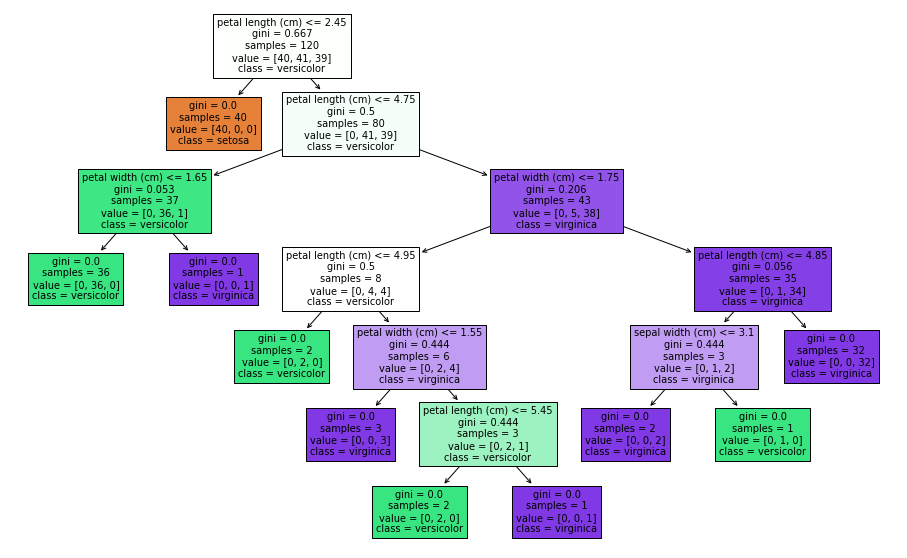

In [12]:
plt.figure(figsize=(16,10))

plot_tree(
    dt,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()

The visualized tree displays the decision-making structure of the tree.
Shows split features, conditions, and predicted classes.

In [13]:
print("Tree Depth:", dt.get_depth())
print("Leaf Nodes:", dt.get_n_leaves())

Tree Depth: 6
Leaf Nodes: 10


Root Node
The top-most node: petal length (cm)

Internal Nodes
Nodes that split further into child nodes: sepal width, sepal length, petal width

Leaf Nodes
Terminal nodes containing the predicted class: species - setosa, versicolor, virginica

Maximum Depth
6

First Split Feature
petal length (cm) becuase it separates Setosa almost perfectly from the other two species, giving the greatest impurity reduction, ie least entropy.

In [14]:
gini = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

gini.fit(X_train, y_train)

gini_pred = gini.predict(X_test)

Creates a tree using Gini impurity to select splits.

In [15]:
entropy = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

entropy.fit(X_train, y_train)

entropy_pred = entropy.predict(X_test)

Uses entropy and Information gain to create splits in nodes. 

In [16]:
comparison = pd.DataFrame({
    "Criterion":["Gini","Entropy"],
    "Accuracy":[
        accuracy_score(y_test,gini_pred),
        accuracy_score(y_test,entropy_pred)
    ],
    "Tree Depth":[
        gini.get_depth(),
        entropy.get_depth()
    ],
    "Leaf Nodes":[
        gini.get_n_leaves(),
        entropy.get_n_leaves()
    ],
    "Root Feature":[
        iris.feature_names[gini.tree_.feature[0]],
        iris.feature_names[entropy.tree_.feature[0]]
    ]
})

print(comparison)

  Criterion  Accuracy  Tree Depth  Leaf Nodes       Root Feature
0      Gini       1.0           6          10  petal length (cm)
1   Entropy       1.0           6          10  petal length (cm)


Compares accuracy, depth, leaves, and root feature.
Helps determine which criterion creates a simpler tree. Here we see both the decision tree methods give similar results.

In [19]:
depths=[1,2,3,4,5,6, None]

results=[]

for d in depths:

    model=DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )

    model.fit(X_train,y_train)

    train_acc=model.score(X_train,y_train)

    test_acc=model.score(X_test,y_test)

    results.append([
        d,
        train_acc,
        test_acc,
        model.get_depth()
    ])

result_df=pd.DataFrame(results,
columns=[
"Max Depth",
"Training Accuracy",
"Testing Accuracy",
"Tree Depth"
])

print(result_df)

   Max Depth  Training Accuracy  Testing Accuracy  Tree Depth
0        1.0           0.675000          0.633333           1
1        2.0           0.950000          0.966667           2
2        3.0           0.958333          1.000000           3
3        4.0           0.975000          1.000000           4
4        5.0           0.991667          1.000000           5
5        6.0           1.000000          1.000000           6
6        NaN           1.000000          1.000000           6


Tests how limiting tree depth affects performance. Helps identify underfitting and overfitting.
max_depth=1 implies Tree is too simple which results in underfitting.
Medium depth (of 5) gives Best balance.
None gives a Very complex tree which might result in possible overfitting.

In [20]:
splits=[2,5,10,20]

results=[]

for s in splits:

    model=DecisionTreeClassifier(
        min_samples_split=s,
        random_state=42
    )

    model.fit(X_train,y_train)

    acc=model.score(X_test,y_test)

    results.append([
        s,
        acc,
        model.get_depth(),
        model.get_n_leaves()
    ])

split_df=pd.DataFrame(results,
columns=[
"min_samples_split",
"Accuracy",
"Tree Depth",
"Leaf Nodes"
])

print(split_df)

   min_samples_split  Accuracy  Tree Depth  Leaf Nodes
0                  2       1.0           6          10
1                  5       1.0           5           8
2                 10       1.0           4           6
3                 20       1.0           4           6


Controls the minimum samples required to create a split. Larger values create simpler trees.
Increasing min_samples_split:
decreases tree complexity
reduces overfitting risk

In [21]:
leaf=[1,2,5,10]

results=[]

for l in leaf:

    model=DecisionTreeClassifier(
        min_samples_leaf=l,
        random_state=42
    )

    model.fit(X_train,y_train)

    acc=model.score(X_test,y_test)

    results.append([
        l,
        acc,
        model.get_depth(),
        model.get_n_leaves()
    ])

leaf_df=pd.DataFrame(results,
columns=[
"min_samples_leaf",
"Accuracy",
"Tree Depth",
"Leaf Nodes"
])

print(leaf_df)

   min_samples_leaf  Accuracy  Tree Depth  Leaf Nodes
0                 1  1.000000           6          10
1                 2  1.000000           5           8
2                 5  1.000000           4           6
3                10  0.966667           4           6


Controls minimum number of samples allowed in each leaf.
Larger values make the tree more generalized.

Increasing min_samples_leaf:
reduces number of leaf nodes
prevents overfitting
may cause underfitting if too large

1. What is the role of the criterion parameter?

The criterion parameter determines how the Decision Tree measures the quality of a split:
Gini Index: Measures impurity/uncertainity based on the probability of misclassification.
Entropy: Uses information gain to select the best split.

The tree chooses the split that produces the purest/least confusion child nodes.

2. How does max_depth influence underfitting and overfitting?

A small max_depth creates a shallow tree that may not capture enough patterns, leading to underfitting.
A large max_depth allows the tree to fit the training data very closely, mugging up, which can lead to overfitting.
An appropriate depth provides a good balance and gives generalized model.

3. Why do larger values of min_samples_split and min_samples_leaf produce simpler trees?

Larger values require more samples before a split is allowed or before a leaf can be created. This prevents unnecessary splitting, resulting in: fewer nodes, smaller tree depth, fewer leaf nodes, reduced model complexity, lower risk of overfitting.

4. Which hyperparameter had the greatest impact?

The max_depth hyperparameter had the greatest impact because it directly controlled the size and complexity of the tree. Lower depths caused underfitting, while unrestricted depth increased the risk of overfitting.

5. Recommend the best Decision Tree model.

Both criterions gave similar results. So, a Decision Tree with max_depth = 5 or max_depth = 6 is the most suitable for the Iris dataset because it achieves high testing accuracy while maintaining a relatively simple tree structure, providing a good balance between model complexity and generalization.